# MLOps Assignment 2 — Fine-Tuning DistilBERT for Goodreads Genre Classification
**Author:** Rohit Patel (G25AIT2089)  
**Course:** MLOps · M.Tech AI Trimester-2 · IIT Jodhpur  
**Instructor:** Dr. Hardik Jain

This notebook fine-tunes a pre-trained DistilBERT model on the UCSD Goodreads reviews dataset for 8-class book genre classification. The pipeline runs on Kaggle's free T4 GPU, tracks every metric on Weights & Biases, logs the evaluation as a versioned W&B Artifact, and publishes the trained model on the Hugging Face Hub.

**Original starter notebook** by Maria Antoniak, Melanie Walsh, and the [AI for Humanists](https://aiforhumanists.com/) team; extended here with the MLOps workflow components (Kaggle Secrets, W&B tracking, Artifact versioning, HF Hub publishing).

<br><br>

## **Import necessary Python libraries and modules**

First, we will import necessary Python libraries and modules. These include as `gdown`, for downloading large files from Google Drive (where we will get our UCSD Goodreads reviews), as well as scikit-learn (`sklearn`) and PyTorch (`torch`), for various machine learning tools.

In [52]:
!pip3 install -U transformers

In [53]:
# Basic Python modules
from collections import defaultdict
import random
import pickle

# For downloading large files from Google Drive
# https://github.com/wkentaro/gdown
import gdown

# For working with gzip files
# https://docs.python.org/3/library/gzip.html
import gzip

# For working with JSON files
import json

# For data manipulation and analysis
import pandas as pd
import numpy as np

# For machine learning tools and evaluation
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# For deep learning
# https://pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html
import torch

# For plotting and data visualization
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import ticker
sns.set(style='ticks', font_scale=1.2)

The HuggingFace [`transformers` Python library](https://huggingface.co/transformers/installation.html) is included in Colab by default now, so we do not need to install it (but this is how you would install it with `pip`).

From `transformers`, we will import modules for `DistilBert`, a *distilled* or smaller version of a BERT model that runs more quickly and uses less computing power. This makes it ideal for those just getting started with BERT.

In [54]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments

<br><br>

## **Set parameters and file paths**

In [55]:
# This is the name of the BERT model that we want to use.
# We're using DistilBERT to save space (it's a distilled version of the full BERT model),
# and we're going to use the cased (vs uncased) version.
model_name = 'distilbert-base-cased'

# This is the name of the program management system for NVIDIA GPUs. We're going to send our code here.
device_name = 'cuda'

# This is the maximum number of tokens in any document sent to BERT.
max_length = 512

# This is the name of the directory where we'll save our model. You can name it whatever you want.
cached_model_directory_name = 'distilbert-reviews-genres'

<br><br>

## **Load and sample Goodreads data**

In this cell, we create a Python dictionary with each genre and the link to the corresponding UCSD Goodreads review data for that genre.

*If you manually click on any of the URLs, you will be able to download the data for that genre. For example, here's the link for poetry: https://datarepo.eng.ucsd.edu/mcauley_group/gdrive/goodreads/byGenre/goodreads_reviews_poetry.json.gz*

In [56]:
# This is where our target data is hosted on the web. You only need these paths for the book review dataset.

# Source: https://mengtingwan.github.io/data/goodreads.html#datasets

genre_url_dict = {'poetry':                 'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_poetry.json.gz',
                  'children':               'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_children.json.gz',
                  'comics_graphic':         'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_comics_graphic.json.gz',
                  'fantasy_paranormal':     'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_fantasy_paranormal.json.gz',
                  'history_biography':      'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_history_biography.json.gz',
                  'mystery_thriller_crime': 'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_mystery_thriller_crime.json.gz',
                  'romance':                'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_romance.json.gz',
                  'young_adult':            'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_young_adult.json.gz'}

Next we loop through this dictionary and use `gdown` to download the Goodreads review data for each genre from Google Drive.

Now we will load the first 100,000 reviews from each link and randomly sample 2,000 reviews.

In [57]:
import requests
# Stream reviews from URL and collect a subset
def load_reviews(url, head=10000, sample_size=2000):
    reviews = []
    count = 0

    response = requests.get(url, stream=True)
    print(response)
    with gzip.open(response.raw, 'rt', encoding='utf-8') as file:
        for line in file:
            d = json.loads(line)
            reviews.append(d['review_text'])
            count += 1

            # Stop if we have reached the 100,000 limit
            if head is not None and count >= head:
                break

    # Return random sample of reviews
    return random.sample(reviews, min(sample_size, len(reviews)))

# Reviews by genre
genre_reviews_dict = {}

# Load reviews for each genre
for genre, url in genre_url_dict.items():
    print(f'Loading reviews for genre: {genre}')
    genre_reviews_dict[genre] = load_reviews(url, head=10000, sample_size=2000)


Loading reviews for genre: poetry
<Response [200]>
Loading reviews for genre: children
<Response [200]>
Loading reviews for genre: comics_graphic
<Response [200]>
Loading reviews for genre: fantasy_paranormal
<Response [200]>
Loading reviews for genre: history_biography
<Response [200]>
Loading reviews for genre: mystery_thriller_crime
<Response [200]>
Loading reviews for genre: romance
<Response [200]>
Loading reviews for genre: young_adult
<Response [200]>


Let's preview a couple of the key-value pairs in `genre_reviews_dict`

In [58]:
 for _genre, _reviews in genre_reviews_dict.items():
    print(_genre)
    print(random.sample(_reviews, 1)[0])

poetry
A gem of a book for anyone who loves fairies, goblins, or whimsy of any kind. Currently out of print, it is well worth seeking out a used copy. You won't find a better way to introduce poetry to children than this!
children
good for early readers. not for storytime.
comics_graphic
see full review @ Katie's Corner 
 I'm continuing with my obsession with Mayu Shinjo's works. However, there are not much left. There definitely be two more reviews, but at that I won't be able to review all of her works, and truly I only review the ones that I found interesting enough to read a second time. But let me get back to the review as talking about my future projects is sometimes boring 
 Please bear in mind that from all of the author's work this is the cruelest. Wait, can I say cruel? Let me elaborate. It's twisted. The story is about love, but Hakuron's (that's the main character and the leader of Hong Kong mafia) idea of love is twisted. The story has lots of murder and also rape, which i

Here we use `pickle` to save this Python dictionary to a `.pickle` file so we can easily load it later.

*The `pickle` module allows you to save and load Python objects like lists and dictionaries.*

In [59]:
pickle.dump(genre_reviews_dict, open('genre_reviews_dict.pickle', 'wb'))
# genre_reviews_dict = pickle.load(open('genre_reviews_dict.pickle', 'rb'))

<br><br>

## **Split the data into training and test sets**

When training a machine learning model, it is necessary to split your training data into two parts: a "training" set and a "test" set.

We will train our BERT model on the "training" set of Goodreads reviews and then we will evaluate how well it is performing by running it on the "test" set of Goodreads reviews that the model has never seen before.

Normally, to tune the hyperparameters, you should also create a "validation" set for tuning, and only use the "test" set once, at the end of all tuning. For simplicity, in this tutorial, we will only using a training and test set.

In [60]:
# Use smaller sample for faster training on Kaggle
train_texts = []
train_labels = []
test_texts = []
test_labels = []

for _genre, _reviews in genre_reviews_dict.items():
    _reviews = random.sample(_reviews, 200)   # 200 reviews per genre
    for _review in _reviews[:160]:
        train_texts.append(_review)
        train_labels.append(_genre)
    for _review in _reviews[160:]:
        test_texts.append(_review)
        test_labels.append(_genre)

print(f'Train: {len(train_texts)} | Test: {len(test_texts)}')

Train: 1280 | Test: 320


Show how many Goodreads reviews and labels we have in each category: 6400 training reviews, 6400 training labels (genres), 1600 test reviews, 1600 test labels (genre)

In [61]:
len(train_texts), len(train_labels), len(test_texts), len(test_labels)

(1280, 1280, 320, 320)

Here's an example of a training label and review:

In [62]:
train_labels[0], train_texts[0]

('poetry', 'I like him very very much.')

<br><br>

## **Run a baseline model (logistic regression)**

Here we train and evaluate a simple TF-IDF baseline model using logistic regression.

We find better-than-random performance, even for a very small dataset. We'll see whether BERT can beat this good baseline!

In [63]:
# Skipped: TF-IDF baseline (not required for MLOps assignment)
# Original code commented out to avoid slow/crash-prone scikit-learn run
# vectorizer = TfidfVectorizer()
# X_train = vectorizer.fit_transform(train_texts)
# X_test = vectorizer.transform(test_texts)
print('Skipping TF-IDF baseline cell — not required for MLOps assignment')

Skipping TF-IDF baseline cell — not required for MLOps assignment


We train a logistic regression model from scikit-learn on the Goodreads training data, and then we use the trained model to make predictions on our Goodreads review test set.

In [64]:
# Skipped: Logistic Regression baseline (not required for MLOps assignment)
# model = LogisticRegression(max_iter=1000).fit(X_train, train_labels)
# predictions = model.predict(X_test)
print('Skipping LogisticRegression baseline — not required for MLOps assignment')

Skipping LogisticRegression baseline — not required for MLOps assignment


We can use scikit-learn's `classification_report` function to evaluate how well the logistic regression model's predictions match up with the true labels for the Goodreads reviews.

Importantly, we can see that our average scores are above random performance (we have 8 classes, so random performance would be ~0.2).

In [65]:
# Skipped: baseline classification report (since baseline was skipped above)
# print(classification_report(test_labels, predictions))
print('Skipping baseline classification_report — moving to BERT fine-tuning')

Skipping baseline classification_report — moving to BERT fine-tuning


<br><br>

## **Encode data for BERT**

We're going to transform our texts and labels into a format that BERT (via Huggingface and PyTorch) will understand. This is called *encoding* the data.

Here are the steps we need to follow:

1. The labels&mdash;in this case, Goodreads genres&mdash;need to be turned into integers rather than strings.

2. The texts&mdash;in this case, Goodreads reviews&mdash;need to be truncated if they're more than 512 tokens or padded if they're fewer than 512 tokens. The tokens, or words in the texts, also need to be separated into "word pieces" and matched to their embedding vectors.

3. We need to add special tokens to help BERT:

| BERT special token | Explanation |
| --------------| ---------|
| [CLS] | Start token of every document. |
| [SEP] | Separator between each sentence |
| [PAD] | Padding at the end of the document as many times as necessary, up to 512 tokens |
|  &#35;&#35; | Start of a "word piece" |




Here we will load `DistilBertTokenizerFast` from the HuggingFace library, which will do all the work of encoding the texts for us. The `tokenizer()` will break word tokens into word pieces, truncate to 512 tokens, and add padding and special BERT tokens.

In [66]:
tokenizer = DistilBertTokenizerFast.from_pretrained(model_name) # The model_name needs to match our pre-trained model.

Here we will create a map of our labels, or Goodreads genres, to integer keys. We take the unique labels, and then we make a dictionary that associates each label/tag with an integer.

**Note:** HuggingFace documentation sometimes refers to "labels" as "tags" but these are the same thing. We use "labels" throughout this notebook for clarity.

In [67]:
unique_labels = set(label for label in train_labels)
label2id = {label: id for id, label in enumerate(unique_labels)}
id2label = {id: label for label, id in label2id.items()}

In [68]:
label2id.keys()

dict_keys(['history_biography', 'comics_graphic', 'mystery_thriller_crime', 'fantasy_paranormal', 'romance', 'children', 'young_adult', 'poetry'])

In [69]:
id2label.keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7])

Now let's encode our texts and labels!

In [70]:
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=max_length)
test_encodings  = tokenizer(test_texts, truncation=True, padding=True, max_length=max_length)

train_labels_encoded = [label2id[y] for y in train_labels]
test_labels_encoded  = [label2id[y] for y in test_labels]

**Examine a Goodreads review in the training set after encoding**

In [71]:
' '.join(train_encodings[0].tokens[0:100])

'[CLS] I like him very very much . [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]'

**Examine a Goodreads review in the test set after encoding**

In [72]:
' '.join(test_encodings[0].tokens[0:100])

'[CLS] I have an ugly secret to di ##vu ##lge - with few exceptions I have not read in their entirety the foundation ##al epic ##s of Western civilization . You name it , chances are good I haven \' t read it : Gil ##game ##sh - no ; Homer - no ; Virgil - no ; Be ##ow ##ulf - no ; The Song of Roland - no ; Ce ##rva ##ntes - no . I could go on with the " roll call of shame " but I \' m sure you get the idea . Oh'

**Examine the training labels after encoding**

In [73]:
set(train_labels_encoded)

{0, 1, 2, 3, 4, 5, 6, 7}

**Examine the test labels after encoding**

In [74]:
set(test_labels_encoded)

{0, 1, 2, 3, 4, 5, 6, 7}

<br><br>

## **Make a custom Torch dataset**

Here we combine the encoded labels and texts into dataset objects. We use the custom Torch `MyDataSet` class to make a `train_dataset` object from  the `train_encodings` and `train_labels_encoded`. We also make a `test_dataset` object from `test_encodings`, and `test_labels_encoded`.

In [75]:
class MyDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [76]:
train_dataset = MyDataset(train_encodings, train_labels_encoded)
test_dataset = MyDataset(test_encodings, test_labels_encoded)

**Examine a Goodreads review in the Torch `training_dataset` after encoding**

In [77]:
' '.join(train_dataset.encodings[0].tokens[0:100])

'[CLS] I like him very very much . [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]'

**Examine a Goodreads review in the Torch `test_dataset` after encoding**

In [78]:
' '.join(test_dataset.encodings[1].tokens[0:100])

'[CLS] Classic Tim . [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]'

<br><br>

## **Load pre-trained BERT model**

Here we load a pre-trained DistilBERT model and send it to CUDA.

**Note:** If you decide to repeat fine-tuning after already running the following cells, make sure that you re-run this cell to re-load the original pre-trained model before fine-tuning again.

In [79]:
# The model_name needs to match the name used for the tokenizer above.
model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=len(id2label)).to(device_name)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


<br><br>

## **Set the BERT fine-tuning parameters**

These are the arguments we'll set in the HuggingFace TrainingArguments objects, which we'll then pass to the HuggingFace Trainer object. There are many more possible arguments, but here we highlight the basics and some common gotchas.

When training your own model, you should search over these parameters to find the best settings for your particular dataset. You should use a held-out set of validation data for this step.

| Parameter | Explanation |
|-----------| ------------|
| num_train_epochs | total number of training epochs (how many times to pass through the entire dataset; too much can cause overfitting) |
| per_device_train_batch_size | batch size per device during training |
| per_device_eval_batch_size |  batch size for evaluation |
|  warmup_steps |  number of warmup steps for learning rate scheduler (set lower because of small dataset size) |
| weight_decay | strength of weight decay (reduces size of weights, like regularization) |
| output_dir | output directory for the fine-tuned model and configuration files |
| logging_dir | directory for storing logs |
| logging_steps | how often to print logging output (so that we can stop training early if the loss isn't going down) |
| evaluation_strategy | evaluate while training so that we can see the accuracy going up |

In [80]:
# Note: This TrainingArguments object is created early in the notebook
# but will be redefined later (cell 74) with W&B logging enabled.
# Keeping this lighter version as a placeholder.
training_args = TrainingArguments(
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=5e-5,
    warmup_steps=50,
    weight_decay=0.01,
    output_dir='./results',
    logging_dir='./logs',
    logging_steps=20,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    report_to=[],   # Disabled here — W&B enabled in later cell
    fp16=True,
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


<br><br>

## **Fine-tune the BERT model**

First, we define a custom evaluation function that returns the accuracy. You could modify this function to return precision, recall, F1, and/or other metrics.

In [81]:
def compute_metrics(pred):
  labels = pred.label_ids
  preds = pred.predictions.argmax(-1)
  acc = accuracy_score(labels, preds)
  return {
      'accuracy': acc,
  }

Then we create a HuggingFace `Trainer` object using the `TrainingArguments` object that we created above. We also send our `compute_metrics` function to the `Trainer` object, along with our test and train datasets.

**Note:** This is what we've been aiming for this whole time! All the work of tokenizing, creating datasets, and setting the training arguments was for this cell.

In [82]:
trainer = Trainer(
    model=model,                         # the instantiated Transformers model to be trained
    args=training_args,                  # training arguments, defined above
    train_dataset=train_dataset,         # training dataset
    eval_dataset=test_dataset,           # evaluation dataset (usually a validation set; here we just send our test set)
    compute_metrics=compute_metrics      # our custom evaluation function
)

Time to finally fine-tune!

Be patient; if you've set everything in Colab to use GPUs, then it should only take a minute or two to run, but if you're running on CPU, it can take hours.

After every 10 steps (as we specified in the TrainingArguments object), the trainer will output the current state of the model, including the training loss, validation ("test") loss, and accuracy (from our `compute_metrics` function).

You should see the loss going down and the accuracy going up. If instead they are staying the same or oscillating, you probably need to change the fine-tuning parameters.

In [83]:
# Turn off weights and biases logging, which requires an API key

import os
# os.environ["WANDB_DISABLED"] = "true"

## Configure the Secrets

In [84]:
# In your Kaggle Notebook — run this first
from kaggle_secrets import UserSecretsClient
 
secrets = UserSecretsClient()
WANDB_API_KEY = secrets.get_secret('WANDB_API_KEY')
HF_TOKEN  	= secrets.get_secret('HF_TOKEN')
 
import os
os.environ['WANDB_API_KEY'] = WANDB_API_KEY
os.environ['HF_TOKEN']      = HF_TOKEN

# Training Script with W&B Integration

In [85]:
# Final compute_metrics — accuracy + F1
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds  = pred.predictions.argmax(-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1':       f1_score(labels, preds, average='weighted'),
    }

# Training arguments WITH W&B logging
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=5e-5,
    warmup_steps=50,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=20,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    report_to='wandb',
    run_name='distilbert-goodreads-rohit',
    fp16=True,
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [86]:
# Clear any cached W&B login from previous Kaggle sessions
import subprocess
subprocess.run(['rm', '-f', '/root/.netrc'], check=False)
subprocess.run(['rm', '-rf', '/root/.config/wandb'], check=False)

import wandb

# No entity= specified — W&B uses the default entity of the API key holder
wandb.init(
    project='mlops-assignment-2',
    name='distilbert-goodreads-rohit',
    config={
        'model': model_name,
        'epochs': 3,
        'batch_size': 16,
        'learning_rate': 5e-5,
        'max_length': max_length,
        'dataset': 'UCSD Goodreads',
        'platform': 'Kaggle',
        'samples_per_genre': 200,
    },
)
print(f'W&B run started: {wandb.run.url}')

eval/accuracy,▁███
eval/f1,▁███
eval/loss,█▂▁▁
eval/runtime,▁▄█▇
eval/samples_per_second,█▅▁▁
eval/steps_per_second,█▅▁▁
final/accuracy,▁
final/f1,▁
final/loss,▁
test/accuracy,▁▁
+10,...


W&B run started: https://wandb.ai/rohitspatel0008/mlops-assignment-2/runs/mlm7knsp


In [87]:
# 4. Train
trainer = Trainer(
	model=model,
	args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)
trainer.train()
 


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,4.024789,3.818423,0.318750,0.265002
2,3.191220,2.877566,0.515625,0.491206
3,2.363972,2.666572,0.534375,0.523551


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=120, training_loss=3.2904953320821124, metrics={'train_runtime': 116.4652, 'train_samples_per_second': 32.971, 'train_steps_per_second': 1.03, 'total_flos': 508729239797760.0, 'train_loss': 3.2904953320821124, 'epoch': 3.0})

<br><br>

## **Save fine-tuned model**

The following cell will save the model and its configuration files to a directory in Colab. To preserve this model for future use, you should download the model to your computer.

In [88]:
trainer.save_model(cached_model_directory_name)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

(Optional) If you've already fine-tuned and saved the model, you can reload it using the following line. You don't have to run fine-tuning every time you want to evaluate.

In [89]:
# SKIPPED: Sharvan's original code overwrote 'trainer' with a model — bug.
# Not needed because we already have the trainer from cell 76.
# trainer = DistilBertForSequenceClassification.from_pretrained(cached_model_directory_name)
print('Skipping reload — using trainer from training cell')

Skipping reload — using trainer from training cell


<br><br>

## **Evaluate fine-tuned model**

But we might want to do more fine-grained analysis of the model, so we extract the predicted labels.

In [90]:
# Use the existing trainer (no need to re-create one)
predicted_results = trainer.predict(test_dataset)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


In [91]:
predicted_results.predictions.shape

(320, 8)

In [92]:
predicted_labels = predicted_results.predictions.argmax(-1) # Get the highest probability prediction
predicted_labels = predicted_labels.flatten().tolist()      # Flatten the predictions into a 1D list
predicted_labels = [id2label[l] for l in predicted_labels]  # Convert from integers back to strings for readability

In [93]:
len(predicted_labels)

320

In [94]:
print(classification_report(test_labels,predicted_labels))

                        precision    recall  f1-score   support

              children       0.51      0.60      0.55        40
        comics_graphic       0.78      0.78      0.78        40
    fantasy_paranormal       0.31      0.38      0.34        40
     history_biography       0.53      0.62      0.57        40
mystery_thriller_crime       0.46      0.42      0.44        40
                poetry       0.68      0.68      0.68        40
               romance       0.59      0.65      0.62        40
           young_adult       0.38      0.15      0.21        40

              accuracy                           0.53       320
             macro avg       0.53      0.53      0.52       320
          weighted avg       0.53      0.53      0.52       320



<br><br>

## **Pull out correct and incorrect classifications for examination**

Let's use our predicted labels for some analysis!

Now that we've fine-tuned and pulled out our predicted labels, the BERT part of this tutorial is done. You can now use the predicted labels in the same way you would use any set of predicted labels from any classification model. We'll show some examples here.

First, let's print out some example predictions that were correct.

In [95]:
for _true_label, _predicted_label, _text in random.sample(list(zip(test_labels, predicted_labels, test_texts)), 20):
  if _true_label == _predicted_label:
    print('LABEL:', _true_label)
    print('REVIEW TEXT:', _text[:100], '...')
    print()

LABEL: children
REVIEW TEXT: When I first bought my kindle, I wanted some books on it, but I didn't want to pay for them (since I ...

LABEL: fantasy_paranormal
REVIEW TEXT: This is a well written book!!! I loved the Vampire Academy books!!! The reason I only gave this book ...

LABEL: comics_graphic
REVIEW TEXT: Trapped by Webnet (5-7). Dr. Silk debuted in the early issues of VH-1 Ninjak (Valiant Masters: Ninja ...

LABEL: children
REVIEW TEXT: Text: 3 stars 
 Art: 5 stars 
 Personally I love this book, and the puppets. I'm a huge fan of recyc ...

LABEL: children
REVIEW TEXT: Simple and sweet, sibling and pirate tale - great for preschool story time. ...

LABEL: mystery_thriller_crime
REVIEW TEXT: Aegean Intrigue is a case where I wish the book was longer. The synopsis made the book sound intrigu ...

LABEL: poetry
REVIEW TEXT: I know more about the other Confessional poets (Plath, Sexton, and Lowell) than I know about Berryma ...

LABEL: poetry
REVIEW TEXT: '`d Dlw`ki , qbl l`nq .. 

Now let's print out some misclassifications.

In [96]:
for _true_label, _predicted_label, _text in random.sample(list(zip(test_labels, predicted_labels, test_texts)), 20):
  if _true_label != _predicted_label:
    print('TRUE LABEL:', _true_label)
    print('PREDICTED LABEL:', _predicted_label)
    print('REVIEW TEXT:', _text[:100], '...')
    print()

TRUE LABEL: romance
PREDICTED LABEL: mystery_thriller_crime
REVIEW TEXT: Sundari Venkatraman is a profilic author who sprinkles her heartwarming romances with nuances of Ind ...

TRUE LABEL: young_adult
PREDICTED LABEL: fantasy_paranormal
REVIEW TEXT: The best thing about Losing Hope, is that it wasn't just Hopeless from a different POV. 
 So much mo ...

TRUE LABEL: fantasy_paranormal
PREDICTED LABEL: comics_graphic
REVIEW TEXT: Leaving off where The Shadow Revolution ended, The Undying Legion remained true. Still full of myste ...

TRUE LABEL: children
PREDICTED LABEL: poetry
REVIEW TEXT: I read this aloud with my seven year old daughter and 10 year old son, and we all loved every minute ...

TRUE LABEL: children
PREDICTED LABEL: fantasy_paranormal
REVIEW TEXT: The male-empowering equivalent of Munsch's Paper Bag Princess. [spoiler alert] Oscar beats the drago ...

TRUE LABEL: children
PREDICTED LABEL: history_biography
REVIEW TEXT: I'm not even a dog person, but I love Danette Hawor

Finally, let's create some heatmaps to examine misclassification patterns. We could use these patterns to think about similarities and differences between genres, according to book reviewers.

In [97]:
genre_classifications_dict = defaultdict(int)
for _true_label, _predicted_label in zip(test_labels, predicted_labels):
  genre_classifications_dict[(_true_label, _predicted_label)] += 1

dicts_to_plot = []
for (_true_genre, _predicted_genre), _count in genre_classifications_dict.items():
  dicts_to_plot.append({'True Genre': _true_genre,
                        'Predicted Genre': _predicted_genre,
                        'Number of Classifications': _count})

df_to_plot = pd.DataFrame(dicts_to_plot)
df_wide = df_to_plot.pivot_table(index='True Genre',
                                 columns='Predicted Genre',
                                 values='Number of Classifications')

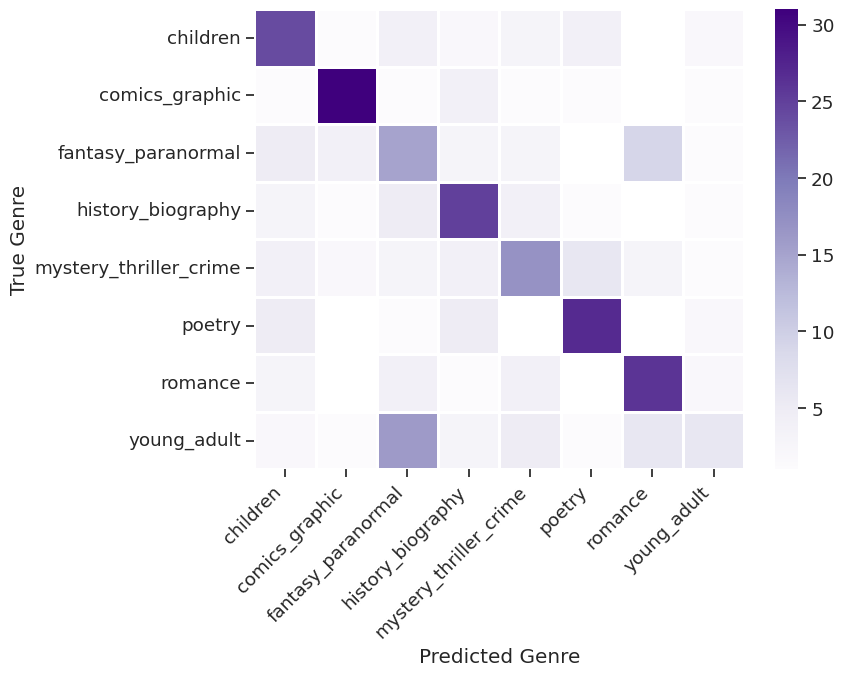

In [98]:
plt.figure(figsize=(9,7))
sns.set(style='ticks', font_scale=1.2)
sns.heatmap(df_wide, linewidths=1, cmap='Purples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Looks good! We can see that overall, our model is assigning the correct labels for each genre.

Now, let's remove the diagonal from the plot to highlight the misclassifications.

In [99]:
genre_classifications_dict = defaultdict(int)
for _true_label, _predicted_label in zip(test_labels, predicted_labels):
  if _true_label != _predicted_label: # Remove the diagonal to highlight misclassifications
    genre_classifications_dict[(_true_label, _predicted_label)] += 1

dicts_to_plot = []
for (_true_genre, _predicted_genre), _count in genre_classifications_dict.items():
  dicts_to_plot.append({'True Genre': _true_genre,
                        'Predicted Genre': _predicted_genre,
                        'Number of Classifications': _count})

df_to_plot = pd.DataFrame(dicts_to_plot)
df_wide = df_to_plot.pivot_table(index='True Genre',
                                 columns='Predicted Genre',
                                 values='Number of Classifications')

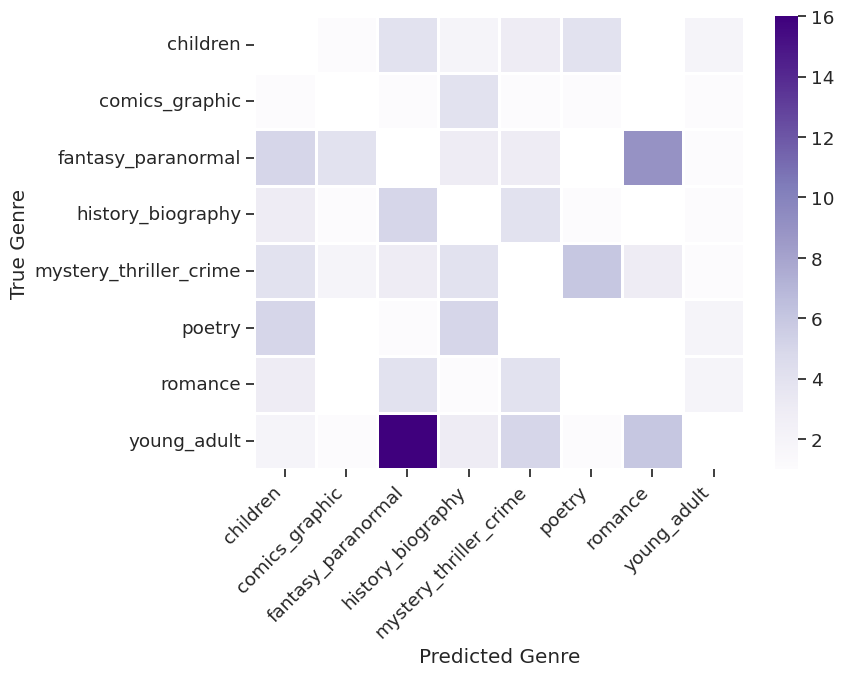

In [100]:
plt.figure(figsize=(9,7))
sns.set(style='ticks', font_scale=1.2)
sns.heatmap(df_wide, linewidths=1, cmap='Purples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

There's much more you can do with your own dataset and labels! Classification can be used to apply a small set of labels across a big dataset; to explore misclassifications to better understand users; and much more! We hope you'll use this tutorial in all kinds of creative ways.

# Eval Report

The following function of the `Trainer` object will run the built-in evaluation, including our `compute_metrics` function.

In [101]:
import json, wandb
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Run final evaluation using the existing trainer
eval_results = trainer.evaluate()
print('Final eval:', eval_results)

# Get predictions for classification report
preds = trainer.predict(test_dataset).predictions.argmax(-1)
labels_int = [item['labels'].item() for item in test_dataset]
final_accuracy = accuracy_score(labels_int, preds)
final_f1       = f1_score(labels_int, preds, average='weighted')

# Log final metrics to W&B explicitly
wandb.log({
    'final/loss':     eval_results['eval_loss'],
    'final/accuracy': final_accuracy,
    'final/f1':       final_f1,
})

# Build full classification report
report = classification_report(
    labels_int, preds,
    target_names=[id2label[i] for i in sorted(id2label)],
    output_dict=True,
)

with open('eval_report.json', 'w') as f:
    json.dump(report, f, indent=2)

# Log report as a versioned W&B Artifact
artifact = wandb.Artifact('eval-report', type='evaluation')
artifact.add_file('eval_report.json')
wandb.log_artifact(artifact)
print('Classification report saved and logged as W&B Artifact')

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Training Loss,Validation Loss,Epoch,Accuracy,F1
2.363972,2.666572,3,0.534375,0.523551


Final eval: {'eval_loss': 2.666572332382202, 'eval_accuracy': 0.534375, 'eval_f1': 0.5235509010232955}


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Classification report saved and logged as W&B Artifact


In [102]:
from huggingface_hub import login

# HF_TOKEN was loaded from Kaggle Secrets in cell 72
login(token=HF_TOKEN)

# IMPORTANT: This pushes to YOUR Hugging Face account
# Confirm your username at huggingface.co/settings/account
HF_USERNAME = 'rpaut03l'
HF_REPO     = f'{HF_USERNAME}/distilbert-goodreads-genres'

model.push_to_hub(HF_REPO)
tokenizer.push_to_hub(HF_REPO)

hf_url = f'https://huggingface.co/{HF_REPO}'
print(f'Model pushed to: {hf_url}')

# Record the HF URL in W&B run summary
wandb.run.summary['huggingface_model'] = hf_url
wandb.run.summary['final_accuracy']    = final_accuracy
wandb.run.summary['final_f1']          = final_f1
wandb.run.summary['final_loss']        = eval_results['eval_loss']

wandb.finish()
print('\n=== PIPELINE COMPLETE ===')
print(f'W&B run:   {wandb.run.url if wandb.run else "see W&B project"}')
print(f'HF model:  {hf_url}')
print(f'Accuracy:  {final_accuracy:.4f}')
print(f'F1 Score:  {final_f1:.4f}')
print(f'Eval Loss: {eval_results["eval_loss"]:.4f}')

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

Model pushed to: https://huggingface.co/rpaut03l/distilbert-goodreads-genres


eval/accuracy,▁▇██
eval/f1,▁▇██
eval/loss,█▂▁▁
eval/runtime,█▁▅▂
eval/samples_per_second,▁█▄▇
eval/steps_per_second,▁█▄▇
final/accuracy,▁
final/f1,▁
final/loss,▁
test/accuracy,▁▁
+10,...



=== PIPELINE COMPLETE ===
W&B run:   see W&B project
HF model:  https://huggingface.co/rpaut03l/distilbert-goodreads-genres
Accuracy:  0.5344
F1 Score:  0.5236
Eval Loss: 2.6666
